Clase Pandas

In [3]:
import pandas as pd
import numpy as np


##Series
Las series son estructuras de unidimensionales. Están construidas sobre un numpy array

In [6]:
array = np.array([1.0,2.4,3.1,4.2,5.8])
s = pd.Series(array)
s

0    1.0
1    2.4
2    3.1
3    4.2
4    5.8
dtype: float64

Tienen un campo index,con el cual se accede a la información, y values, la información en sí.

In [8]:
display(s.index)
display(s.values)

RangeIndex(start=0, stop=5, step=1)

array([1. , 2.4, 3.1, 4.2, 5.8])

Se puede hacer operaciones

In [11]:
s * 2 + (s - 1)

0     2.0
1     6.2
2     8.3
3    11.6
4    16.4
dtype: float64

In [12]:
s < 4

0     True
1     True
2     True
3    False
4    False
dtype: bool

In [ ]:
(s > 4) & (s < 3) # Conjunciones

0    False
1    False
2    False
3    False
4    False
dtype: bool

In [16]:
(s > 4) | (s < 3)

0     True
1     True
2    False
3     True
4     True
dtype: bool

In [17]:
(s > 4) | (s > 3)

0    False
1    False
2     True
3     True
4     True
dtype: bool

In [18]:
(s > 4) & (s > 3)

0    False
1    False
2    False
3     True
4     True
dtype: bool

In [22]:
filter_index = (s > 4) | (s < 3)

In [23]:
s[filter_index]

0    1.0
1    2.4
3    4.2
4    5.8
dtype: float64

In [25]:
s1 = pd.Series([0,1,2,3,4])
s2 = pd.Series([5,6,7,8,9])

In [30]:
s1 == s2 

0    False
1    False
2    False
3    False
4    False
dtype: bool

##DataFrame
Los dataframes son estructuras de dos dimensiones, con tamaño mutable y con tipos heterogeneos. Es lo que conocemos como tabla.

In [51]:
df = pd.DataFrame(data = [s1,s2])
df.columns = ['A','B','C','D','E']
df.index = ["primero", "segundo"]
df

,A,B,C,D,E
primero,0,1,2,3,4
segundo,5,6,7,8,9


In [32]:
display(df.index, df.columns, df.values)

Index(['primero', 'segundo'], dtype='str')

Index(['A', 'B', 'C', 'D', 'E'], dtype='str')

array([[0, 1, 2, 3, 4],
       [5, 6, 7, 8, 9]])

##Estadística Descriptivas
Podemos obtener estadísticas mas avanzadas que con numpy arrays

In [35]:
df.mean()

A    2.5
B    3.5
C    4.5
D    5.5
E    6.5
dtype: float64

In [34]:
display(df.mean(axis = 0))
display(df.mean(axis = 1)) #Medias por columnas y por fila

A    2.5
B    3.5
C    4.5
D    5.5
E    6.5
dtype: float64

primero    2.0
segundo    7.0
dtype: float64

In [37]:
df.std()

A    3.535534
B    3.535534
C    3.535534
D    3.535534
E    3.535534
dtype: float64

In [ ]:
display(df.std(axis = 0))
display(df.std(axis = 1))

A    3.535534
B    3.535534
C    3.535534
D    3.535534
E    3.535534
dtype: float64

primero    1.581139
segundo    1.581139
dtype: float64

In [39]:
df.mode()

,A,B,C,D,E
0,0,1,2,3,4
1,5,6,7,8,9


In [40]:
df.describe()

,A,B,C,D,E
count,2.000000,2.000000,2.000000,2.000000,2.000000
mean,2.500000,3.500000,4.500000,5.500000,6.500000
std,3.535534,3.535534,3.535534,3.535534,3.535534
min,0.000000,1.000000,2.000000,3.000000,4.000000
25%,1.250000,2.250000,3.250000,4.250000,5.250000
50%,2.500000,3.500000,4.500000,5.500000,6.500000
75%,3.750000,4.750000,5.750000,6.750000,7.750000
max,5.000000,6.000000,7.000000,8.000000,9.000000


In [44]:
df.quantile(0.5)

A    2.5
B    3.5
C    4.5
D    5.5
E    6.5
Name: 0.5, dtype: float64

In [45]:
df.var()

A    12.5
B    12.5
C    12.5
D    12.5
E    12.5
dtype: float64

## INgenieria de datos

In [65]:
df.drop(columns=["C"])

,A,D,E,F
primero,0,3,4,4
segundo,5,8,9,19


In [67]:
df["F"] = df["A"] + 2 * df["C"]
df["G"] = df["D"] + 3 + df["A"]
df

,A,C,D,E,F,G
primero,0,2,3,4,4,6
segundo,5,7,8,9,19,16


In [68]:
df.isna() #vemos si hay datos nulos

,A,C,D,E,F,G
primero,False,False,False,False,False,False
segundo,False,False,False,False,False,False


In [74]:
filter_index = (df["A"] > 4) | (df["C"] < 3)
df_filtrado = df[filter_index]

print(df_filtrado)

     A    B     C     D     E
1  6.0  7.0   8.0   9.0  10.0
4  8.0  9.0  10.0  11.0  12.0


In [71]:
s1 = pd.Series([1,2,np.nan,4,5])
s2 = pd.Series([6,7,8,9,10])
df = pd.DataFrame(data = [s1,s2,s2*0.5,s1*0.1,s2+2])
df.columns = ['A','B','C','D','E']
df

,A,B,C,D,E
0,1.0,2.0,NaN,4.0,5.0
1,6.0,7.0,8.0,9.0,10.0
2,3.0,3.5,4.0,4.5,5.0
3,0.1,0.2,NaN,0.4,0.5
4,8.0,9.0,10.0,11.0,12.0


In [76]:
display(df.fillna(0))
display(df.dropna(axis = 1))

,A,B,C,D,E
0,1.0,2.0,0.0,4.0,5.0
1,6.0,7.0,8.0,9.0,10.0
2,3.0,3.5,4.0,4.5,5.0
3,0.1,0.2,0.0,0.4,0.5
4,8.0,9.0,10.0,11.0,12.0


,A,B,D,E
0,1.0,2.0,4.0,5.0
1,6.0,7.0,9.0,10.0
2,3.0,3.5,4.5,5.0
3,0.1,0.2,0.4,0.5
4,8.0,9.0,11.0,12.0


In [2]:
import matplotlib as plt
import seaborn as sns

In [5]:
data = sns.load_dataset("iris")
data

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [87]:
data.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


<Axes: xlabel='species', ylabel='sepal_length'>

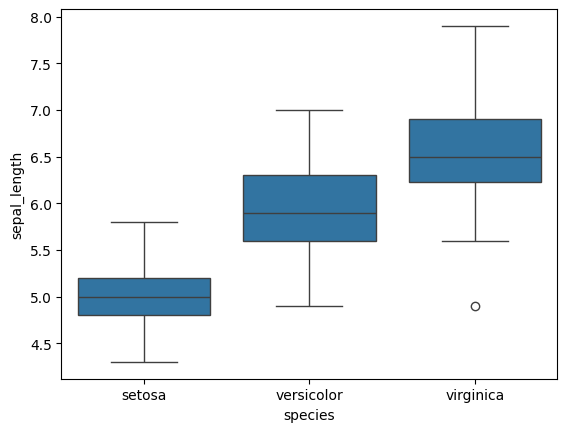

In [91]:
sns.boxplot(data=data, x="species", y="sepal_length")


<Axes: xlabel='species', ylabel='count'>

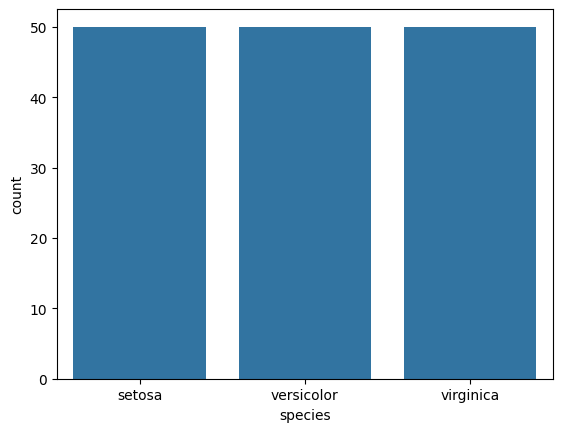

In [6]:
sns.countplot(data=data, x="species")

<Axes: xlabel='sepal_length', ylabel='Count'>

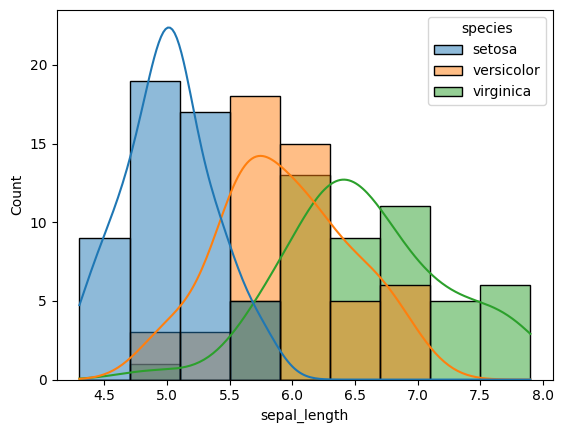

In [93]:
sns.histplot(data=data, x="sepal_length", hue="species", kde=True)